In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anastruct as ast

In [2]:
L_x = [6] # m
h_z = [4,3] # m
at = 6 # m

In [3]:
fc = 280 # kg/cm²
Ec = 15000 * fc**0.5 * 10 # ton/m²

c_b = 0.5
c_h = 0.5
v_b = 0.3
v_h = 0.6

A_c = c_b * c_h
I_c = c_b * c_h**3 / 12
A_v = v_b * v_h
I_v = v_b * v_h**3 / 12

In [4]:
ejes_x = [0]
for x in L_x: ejes_x.append(ejes_x[-1]+x)

ejes_z = [0]
for z in h_z: ejes_z.append(ejes_z[-1]+z)
print(ejes_x)
print(ejes_z)

[0, 6]
[0, 4, 7]


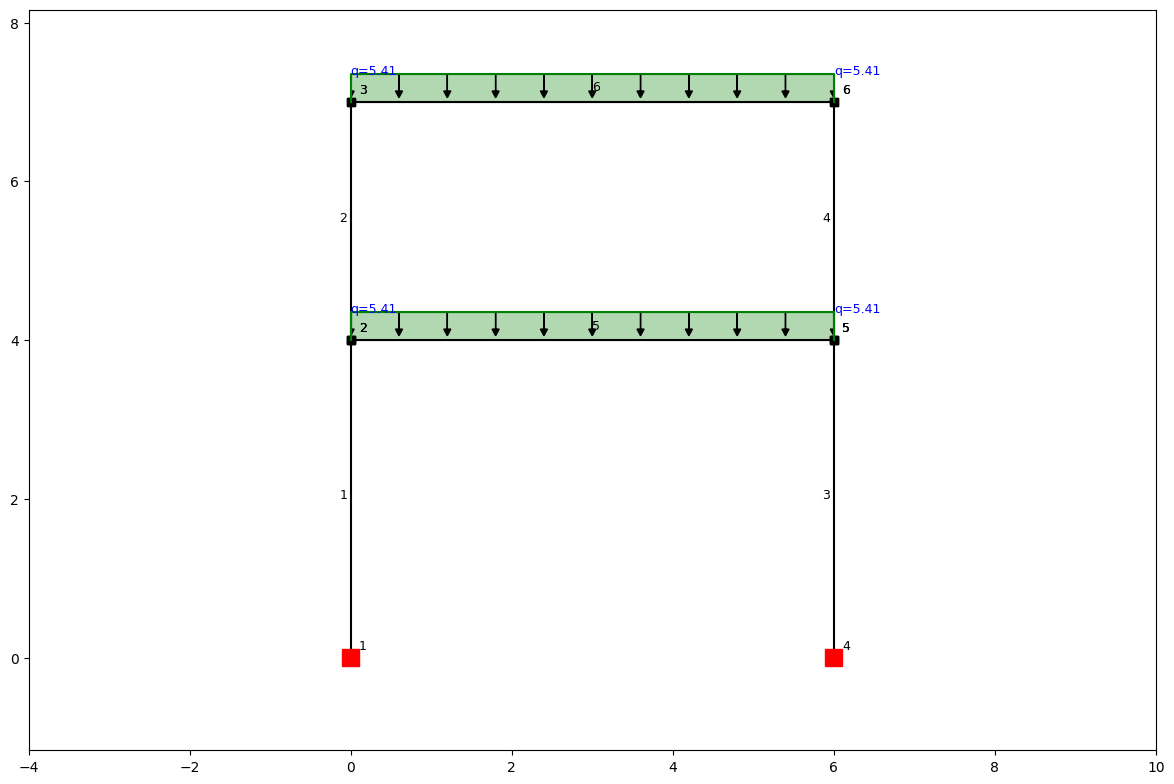

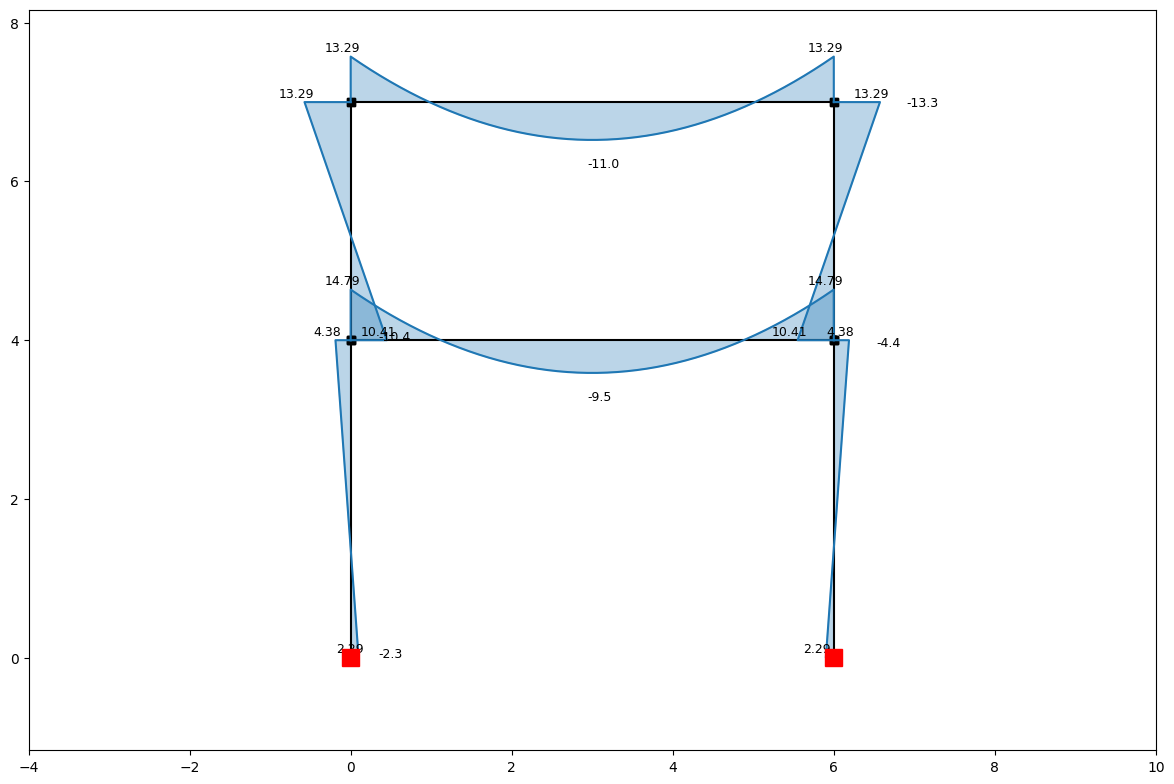

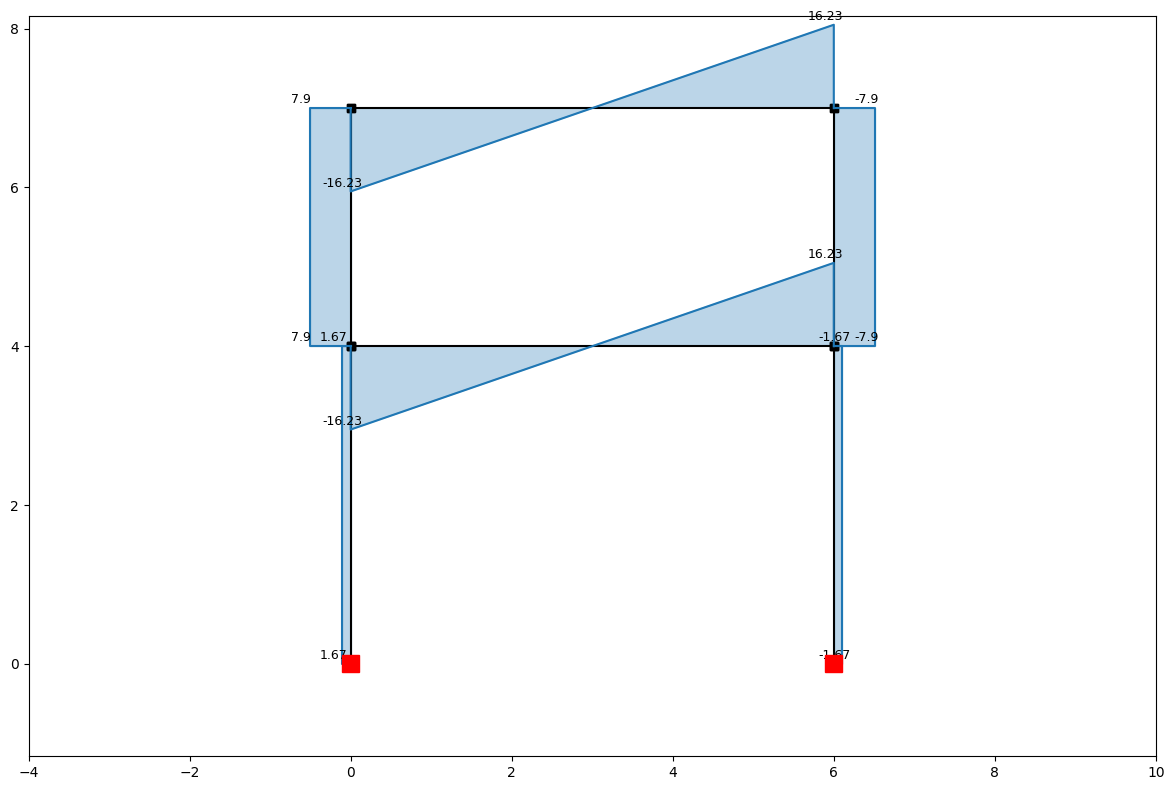

{'id': 1,
 'length': 4.0,
 'alpha': 1.5707963267948966,
 'umax': np.float64(-0.00011651524560535442),
 'umin': np.float64(-0.0002199311440716453),
 'u': array([-0.00021993, -0.00021166, -0.00020373, -0.00019615, -0.00018891,
        -0.00018201, -0.00017546, -0.00016926, -0.0001634 , -0.00015788,
        -0.00015271, -0.00014788, -0.0001434 , -0.00013927, -0.00013547,
        -0.00013203, -0.00012893, -0.00012617, -0.00012375, -0.00012169,
        -0.00011996, -0.00011858, -0.00011755, -0.00011686, -0.00011652,
        -0.00011652, -0.00011686, -0.00011755, -0.00011858, -0.00011996,
        -0.00012169, -0.00012375, -0.00012617, -0.00012893, -0.00013203,
        -0.00013547, -0.00013927, -0.0001434 , -0.00014788, -0.00015271,
        -0.00015788, -0.0001634 , -0.00016926, -0.00017546, -0.00018201,
        -0.00018891, -0.00019615, -0.00020373, -0.00021166, -0.00021993]),
 'wmax': np.float64(-0.00019172359570408578),
 'wmin': np.float64(1.1154528866639825e-06),
 'w': array([-5.83591555e

In [ ]:
ss = ast.SystemElements()

# modelamiento de columnas
for i in range(len(ejes_x)):
    for j in range(len(h_z)):
        ss.add_element([[ejes_x[i],ejes_z[j]],[ejes_x[i],ejes_z[j+1]]], EA = Ec*A_c, EI = Ec*I_c)

# modelamiento de vigas
for i in range(len(h_z)):
    for j in range(len(L_x)):
        ss.add_element([[ejes_x[j],ejes_z[i+1]],[ejes_x[j+1],ejes_z[i+1]]], EA = Ec*A_v, EI = Ec*I_v)

# Asignación de apoyos empotrados

for i in range(len(ejes_x)):
    ss.add_support_fixed(node_id=len(ejes_z)*i+1)

# Asignación de cargas

# Load Case Dead
w1 = 2.4 * 0.2 * at # Peso propio de la losa, ton/m
w2 = 2.4 * A_v # Peso propio de la viga, ton/m
w3 = at * (0.100 + 0.250) # acabados + tabiquería, ton/m
lc_D = ast.LoadCase("Dead")
for viga in range(len(ejes_x)*len(h_z)+1,len(ejes_x)*len(h_z)+len(h_z)*len(L_x)+1):
    lc_D.q_load(q = -round(w1+w2+w3,2), element_id=viga)#, direction="y")

# Load Case Live
l1 = 0.250 * at # Peso propio de la losa, ton/m
lc_L = ast.LoadCase("Live")
for viga in range(len(ejes_x)*len(h_z)+1,len(ejes_x)*len(h_z)+len(h_z)*len(L_x)+1):
    lc_L.q_load(q = -round(l1,2), element_id=viga)#, direction="y")


# Load Case EarthQuake
lc_E = ast.LoadCase("EarthQuake")
E = [100, 130, 150,180]
for i in range(len(h_z)):
    for j in range(len(ejes_x)):
        lc_E.point_load(Fx=round(E[i]/len(ejes_x),1), node_id=2+j*len(ejes_z)+i)

Comb1 = ast.LoadCombination("Combo 1")
Comb1.add_load_case(lc_D, 1.4)
Comb1.add_load_case(lc_L, 1.7)

Comb2 = ast.LoadCombination("Combo 2")
Comb2.add_load_case(lc_D, 1.25)
Comb2.add_load_case(lc_L, 1.25)
Comb2.add_load_case(lc_E, 1)

Comb3 = ast.LoadCombination("Combo 3")
Comb3.add_load_case(lc_D, 1.25)
Comb3.add_load_case(lc_L, 1.25)
Comb3.add_load_case(lc_E, -1)

Comb4 = ast.LoadCombination("Combo 4")
Comb4.add_load_case(lc_D, 0.90)
Comb4.add_load_case(lc_E, 1)

Comb5 = ast.LoadCombination("Combo 5")
Comb5.add_load_case(lc_D, 0.90)
Comb5.add_load_case(lc_E, -1)

ss.apply_load_case(lc_D)
ss.solve()
ss.show_structure()
ss.show_bending_moment()
ss.show_shear_force()

ss.get_element_results(element_id=1, verbose=True)


c:\Users\lcano\AppData\Local\Programs\Python\Python313\Lib\site-packages\anastruct\fem\plotter\mpl.py:573: RuntimeWarning: divide by zero encountered in scalar divide
  h = 0.1 * max_plot_range * F / self.max_system_point_load
c:\Users\lcano\AppData\Local\Programs\Python\Python313\Lib\site-packages\anastruct\fem\plotter\mpl.py:552: RuntimeWarning: invalid value encountered in scalar multiply
  len_y = -Fy / F * h
c:\Users\lcano\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\patches.py:1533: RuntimeWarning: invalid value encountered in add
  left_half_arrow += [head_length, 0]
c:\Users\lcano\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\patches.py:1553: RuntimeWarning: invalid value encountered in scalar divide
  cx = self._dx / distance
c:\Users\lcano\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\patches.py:1560: RuntimeWarning: invalid value encountered in scalar add
  self._x + self._dx,


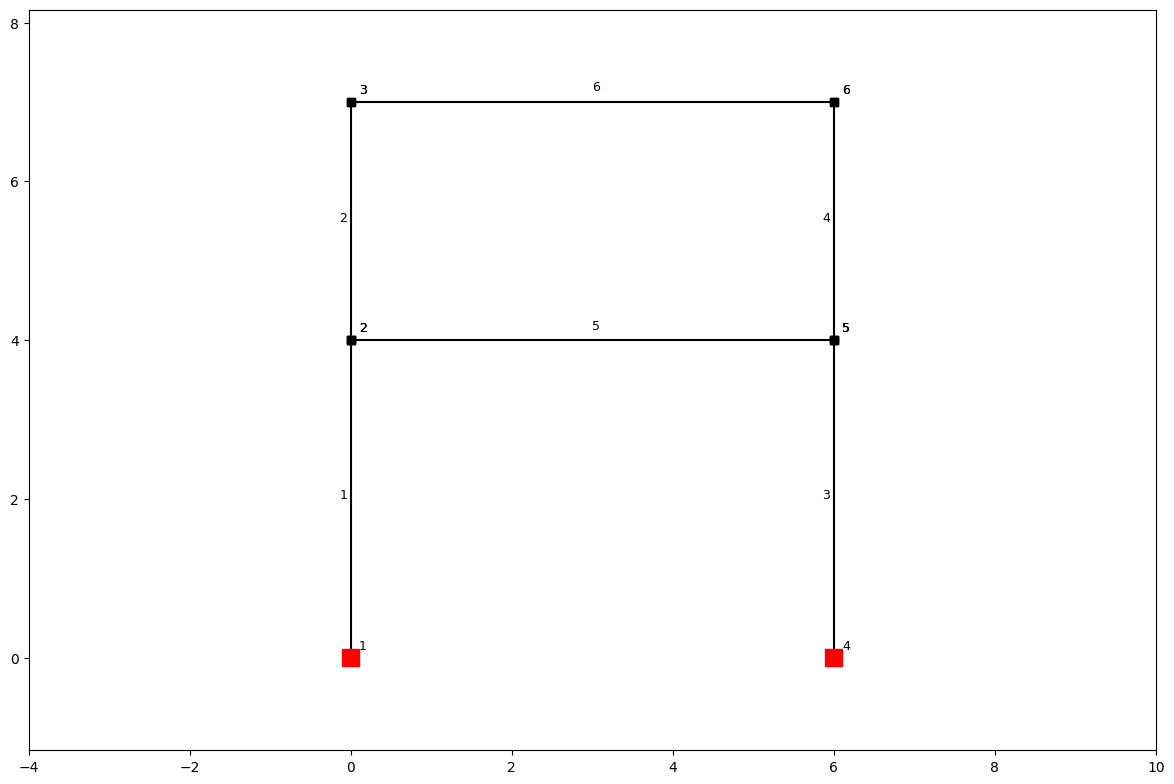

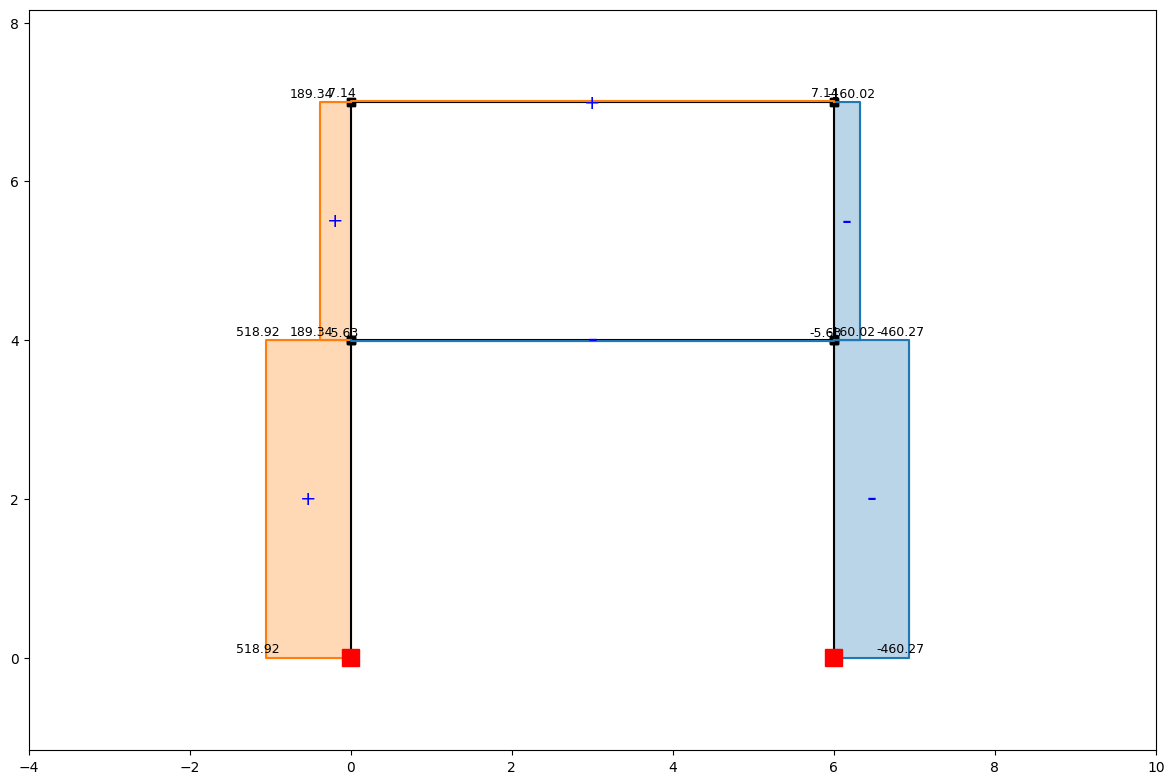

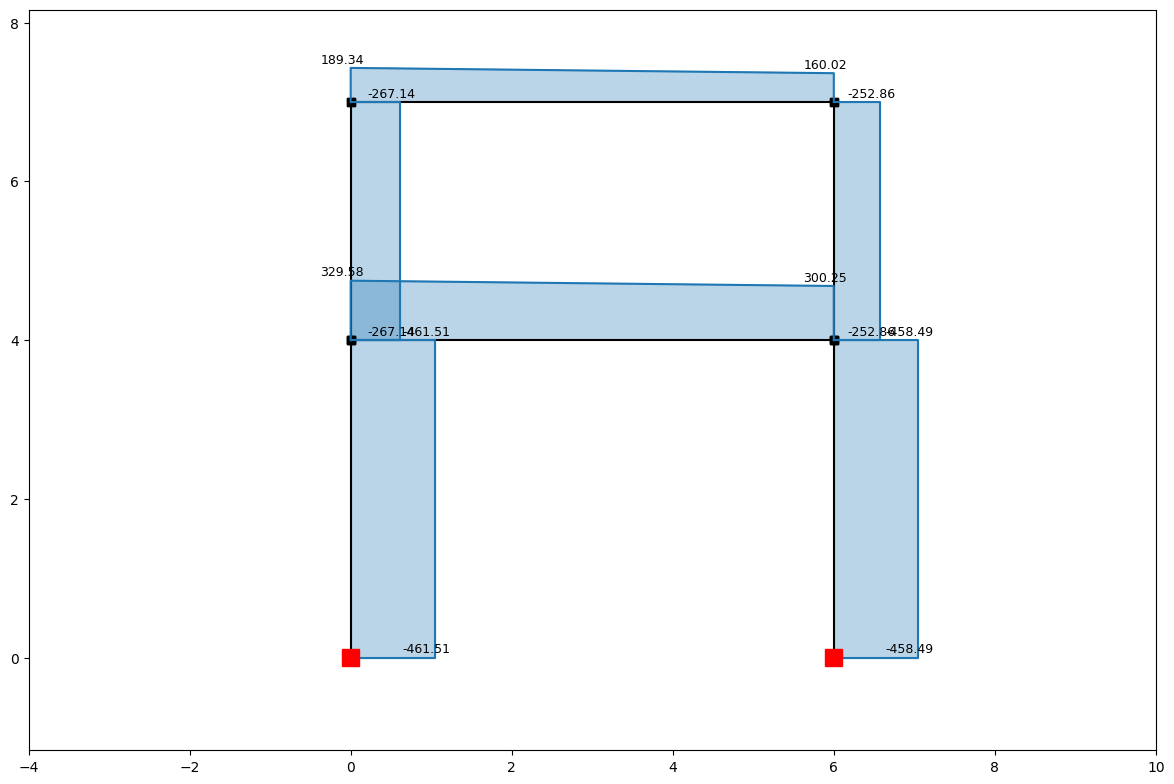

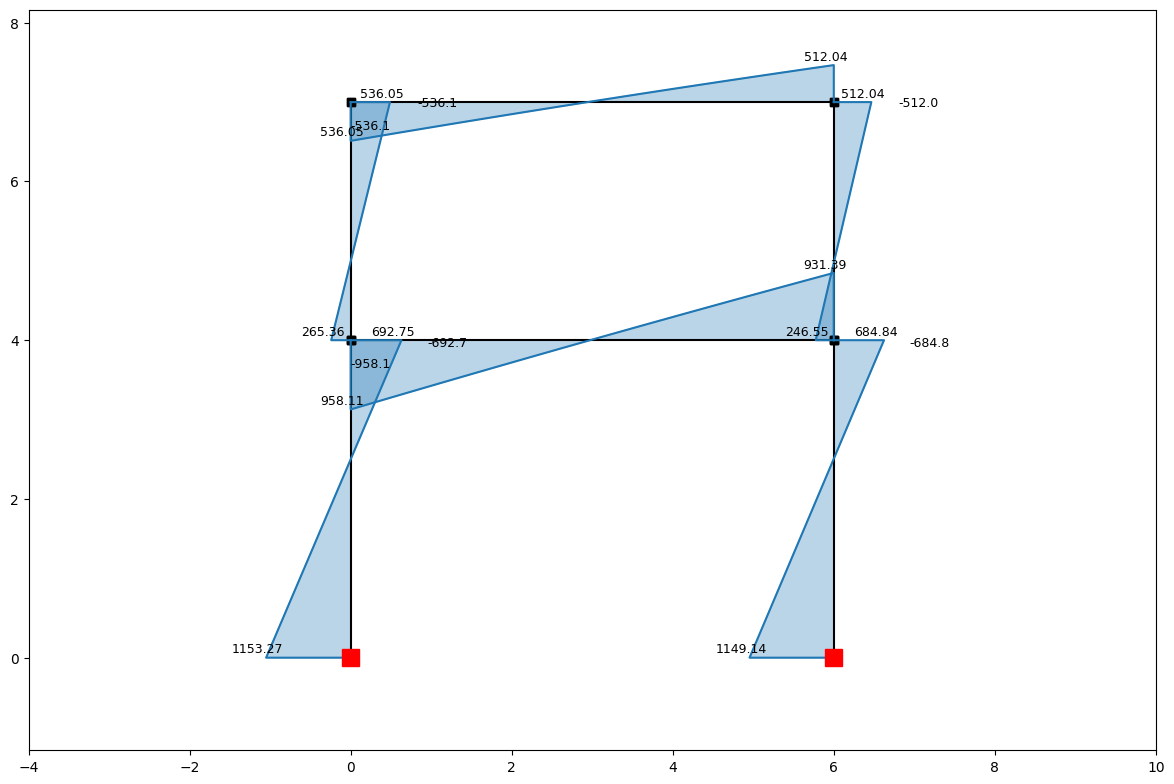

{'id': 6,
 'length': 6.0,
 'alpha': 0.0,
 'umax': np.float64(0.00015114361105460965),
 'umin': np.float64(8.007294754930729e-05),
 'u': array([1.51143611e-04, 1.45457958e-04, 1.40009207e-04, 1.34797358e-04,
        1.29822412e-04, 1.25084368e-04, 1.20583226e-04, 1.16318986e-04,
        1.12291648e-04, 1.08501213e-04, 1.04947680e-04, 1.01631049e-04,
        9.85513201e-05, 9.57084935e-05, 9.31025692e-05, 9.07335471e-05,
        8.86014272e-05, 8.67062095e-05, 8.50478940e-05, 8.36264807e-05,
        8.24419697e-05, 8.14943608e-05, 8.07836542e-05, 8.03098498e-05,
        8.00729475e-05, 8.00729475e-05, 8.03098498e-05, 8.07836542e-05,
        8.14943608e-05, 8.24419697e-05, 8.36264807e-05, 8.50478940e-05,
        8.67062095e-05, 8.86014272e-05, 9.07335471e-05, 9.31025692e-05,
        9.57084935e-05, 9.85513201e-05, 1.01631049e-04, 1.04947680e-04,
        1.08501213e-04, 1.12291648e-04, 1.16318986e-04, 1.20583226e-04,
        1.25084368e-04, 1.29822412e-04, 1.34797358e-04, 1.40009207e-04,
 

In [6]:

"""
ss.solve()
ss.show_structure(scale=0.7)
ss.show_bending_moment()
ss.show_axial_force()
ss.show_displacement(scale=0.7)
"""

res = Comb2.solve(ss)
s1 = res["combination"]
s1.show_structure()
#s1.show_shear_force()
#s1.show_reaction_force(scale=0.7)
s1.show_axial_force(scale=1)
s1.show_shear_force(scale=1)
s1.show_bending_moment(scale=1)

s1.get_element_results(element_id=6, verbose=True)